In [114]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_colored_grid_only(
    values,
    save_path="colored_grid.pdf",
    cmap="viridis",
    vmin=None,
    vmax=None,
    show_values=False,
    grid_color="white",
    grid_lw=0.8,
    figsize_per_cell=0.35,
    dpi=300,
):
    """
    只画网格主图，不画 colorbar。
    save_path 可以是 .pdf / .png / .svg 等格式。
    """
    values = np.asarray(values)
    if values.ndim != 2:
        raise ValueError("values 必须是二维矩阵")

    n_rows, n_cols = values.shape
    print(f"Grid size: {n_rows} rows × {n_cols} cols = {n_rows * n_cols} cells")

    if vmin is None:
        vmin = np.nanmin(values)
    if vmax is None:
        vmax = np.nanmax(values)

    fig_w = max(2, n_cols * figsize_per_cell)
    fig_h = max(2, n_rows * figsize_per_cell)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    x = np.arange(n_cols + 1)
    y = np.arange(n_rows + 1)

    mesh = ax.pcolormesh(
        x,
        y,
        values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolors=grid_color,
        linewidth=grid_lw,
        shading="flat",
    )

    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    if show_values:
        for i in range(n_rows):
            for j in range(n_cols):
                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{values[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="black",
                )

    #plt.tight_layout()

    # 自动根据 save_path 后缀保存，例如 .pdf / .png / .svg
    ax.set_position([0, 0, 1, 1])  # 让坐标轴占满整个 figure

    plt.savefig(
        save_path,
        bbox_inches="tight",
        pad_inches=0,
        dpi=dpi,
    )

    print(f"Main figure saved to: {save_path}")


def save_colorbar_only(
    save_path="colorbar.pdf",
    cmap="viridis",
    vmin=0,
    vmax=1,
    orientation="vertical",   # "vertical" or "horizontal"
    label=None,
    ticks=None,
    tick_labels=None,
    tick_label_mode="range",  # "range", "numeric", or "custom"
    tick_fontsize=12,
    label_fontsize=14,
    figsize=None,
    dpi=300,
    pad_inches=0,
):
    """
    单独保存一个只有 colorbar 的图。

    参数
    ----
    figsize:
        控制输出图像尺寸。
        vertical 推荐例如 (0.45, 3.5)
        horizontal 推荐例如 (3.5, 0.45)

    tick_label_mode:
        "range"   : 只显示 0 和 max
        "numeric" : 显示具体数值
        "custom"  : 使用 tick_labels
    """
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    if figsize is None:
        if orientation == "vertical":
            figsize = (0.45, 3.5)
        elif orientation == "horizontal":
            figsize = (3.5, 0.45)
        else:
            raise ValueError("orientation 必须是 'vertical' 或 'horizontal'")

    fig, ax = plt.subplots(figsize=figsize)

    cbar = fig.colorbar(sm, cax=ax, orientation=orientation)

    # =========================
    # tick 设置
    # =========================
    if ticks is None:
        ticks = [vmin, vmax]

    cbar.set_ticks(ticks)

    if tick_label_mode == "range":
        # 只显示 0 和 max，不显示具体 vmax 数字
        if len(ticks) == 2:
            cbar.set_ticklabels(["0", "max"])
        else:
            # 如果用户给了多个 ticks，则默认只给首尾语义标签
            labels = [""] * len(ticks)
            labels[0] = "0"
            labels[-1] = "max"
            cbar.set_ticklabels(labels)

    elif tick_label_mode == "numeric":
        # 显示真实数值
        cbar.set_ticklabels([f"{t:g}" for t in ticks])

    elif tick_label_mode == "custom":
        if tick_labels is None:
            raise ValueError("tick_label_mode='custom' 时必须提供 tick_labels")
        if len(tick_labels) != len(ticks):
            raise ValueError("tick_labels 的长度必须和 ticks 一致")
        cbar.set_ticklabels(tick_labels)

    else:
        raise ValueError("tick_label_mode 必须是 'range', 'numeric', 或 'custom'")

    cbar.ax.tick_params(
        labelsize=tick_fontsize,
        length=3,
        width=0.8,
    )

    if label is not None:
        cbar.set_label(label, fontsize=label_fontsize)

    # 去掉 figure 内部边距
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

    plt.savefig(
        save_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=pad_inches,
    )
    plt.close(fig)

    print(f"Colorbar saved to: {save_path}")

def plot_patch_motion_timeseries(
    motion_data,
    patch_coord,
    component="magnitude",   # "x", "y", "magnitude", "xy", "all"
    time_axis=None,
    figsize=(6, 4),
    title=None,
    xlabel="Time",
    ylabel=None,
    color="tab:blue",
    marker="o",
    linestyle="-",
    linewidth=2.0,
    markersize=5,
    alpha=1.0,
    x_style=None,
    y_style=None,
    mag_style=None,
    show_grid=True,
    grid_alpha=0.3,
    save_path=None,
    dpi=300,
    show=True,
):
    """
    绘制指定 patch 的 motion 随时间变化曲线。

    Parameters
    ----------
    motion_data : np.ndarray
        支持两种格式：
        1) (T, X, Y, 2): 每个 patch 的 2D motion 向量
        2) (T, X, Y): 每个 patch 的 motion magnitude / score

    patch_coord : tuple
        patch 坐标，格式为 (px, py)

    component : str
        当 motion_data.shape == (T, X, Y, 2) 时可选：
        - "x"         : 只画 x 分量
        - "y"         : 只画 y 分量
        - "magnitude" : 只画模长
        - "xy"        : 同时画 x 和 y
        - "all"       : 同时画 x、y、magnitude

        当 motion_data.shape == (T, X, Y) 时，会忽略该参数，直接画该 patch 的值。

    time_axis : array-like or None
        横坐标时间轴。若为 None，则自动使用 np.arange(T)

    figsize : tuple
        图像尺寸

    title : str or None
        图标题

    color, marker, linestyle, linewidth, markersize, alpha
        单曲线情况下的样式设置

    x_style, y_style, mag_style : dict or None
        当 component="xy" 或 "all" 时，可以分别指定每条曲线的样式。
        例如：
        x_style={"color":"red","marker":"o","linestyle":"-"}
        y_style={"color":"blue","marker":"s","linestyle":"--"}
        mag_style={"color":"black","marker":"^","linestyle":"-."}

    show_grid : bool
        是否显示网格

    save_path : str or None
        若不为 None，则保存图片

    dpi : int
        保存图分辨率

    show : bool
        是否 plt.show()

    Returns
    -------
    series_dict : dict
        返回所绘制的时间序列，便于后续分析
    """
    motion_data = np.asarray(motion_data)

    if motion_data.ndim not in [3, 4]:
        raise ValueError("motion_data 必须是 (T, X, Y) 或 (T, X, Y, 2)")

    px, py = patch_coord

    T = motion_data.shape[0]

    if time_axis is None:
        time_axis = np.arange(T)
    else:
        time_axis = np.asarray(time_axis)
        if len(time_axis) != T:
            raise ValueError("time_axis 长度必须等于 T")

    # 检查 patch 坐标是否合法
    if motion_data.ndim == 4:
        _, X, Y, C = motion_data.shape
        if C != 2:
            raise ValueError("若为4维输入，最后一维必须是2，对应 (dx, dy)")
    else:
        _, X, Y = motion_data.shape

    if not (0 <= px < X and 0 <= py < Y):
        raise ValueError(f"patch_coord={patch_coord} 越界，合法范围为 x:[0,{X-1}], y:[0,{Y-1}]")

    fig, ax = plt.subplots(figsize=figsize)

    series_dict = {}

    # -------------------------
    # 情况1：输入是 (T, X, Y)
    # -------------------------
    if motion_data.ndim == 3:
        series = motion_data[:, px, py]
        series_dict["value"] = series

        if ylabel is None:
            ylabel = "Motion"

        ax.plot(
            time_axis,
            series,
            color=color,
            marker=marker,
            linestyle=linestyle,
            linewidth=linewidth,
            markersize=markersize,
            alpha=alpha,
            label=f"Patch ({px}, {py})"
        )

    # -------------------------
    # 情况2：输入是 (T, X, Y, 2)
    # -------------------------
    else:
        dx = motion_data[:, px, py, 0]
        dy = motion_data[:, px, py, 1]
        mag = np.sqrt(dx**2 + dy**2)

        series_dict["x"] = dx
        series_dict["y"] = dy
        series_dict["magnitude"] = mag

        if ylabel is None:
            ylabel = "Motion"

        # 默认样式
        default_x_style = dict(color="tab:red", marker="o", linestyle="-", linewidth=2, markersize=5, alpha=1.0)
        default_y_style = dict(color="tab:blue", marker="s", linestyle="--", linewidth=2, markersize=5, alpha=1.0)
        default_mag_style = dict(color="tab:green", marker="^", linestyle="-.", linewidth=2, markersize=5, alpha=1.0)

        if x_style is not None:
            default_x_style.update(x_style)
        if y_style is not None:
            default_y_style.update(y_style)
        if mag_style is not None:
            default_mag_style.update(mag_style)

        if component == "x":
            ax.plot(
                time_axis, dx,
                color=color, marker=marker, linestyle=linestyle,
                linewidth=linewidth, markersize=markersize, alpha=alpha,
                label=f"dx @ ({px}, {py})"
            )

        elif component == "y":
            ax.plot(
                time_axis, dy,
                color=color, marker=marker, linestyle=linestyle,
                linewidth=linewidth, markersize=markersize, alpha=alpha,
                label=f"dy @ ({px}, {py})"
            )

        elif component == "magnitude":
            ax.plot(
                time_axis, mag,
                color=color, marker=marker, linestyle=linestyle,
                linewidth=linewidth, markersize=markersize, alpha=alpha,
                label=f"|motion| @ ({px}, {py})"
            )

        elif component == "xy":
            ax.plot(time_axis, dx, label=f"dx @ ({px}, {py})", **default_x_style)
            ax.plot(time_axis, dy, label=f"dy @ ({px}, {py})", **default_y_style)

        elif component == "all":
            ax.plot(time_axis, dx, label=f"dx @ ({px}, {py})", **default_x_style)
            ax.plot(time_axis, dy, label=f"dy @ ({px}, {py})", **default_y_style)
            ax.plot(time_axis, mag, label=f"|motion| @ ({px}, {py})", **default_mag_style)

        else:
            raise ValueError("component 必须是 'x', 'y', 'magnitude', 'xy', 'all'")

    if title is None:
        title = f"Patch motion over time: ({px}, {py})"

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if show_grid:
        ax.grid(True, alpha=grid_alpha)

    ax.legend(frameon=False)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0.02)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return series_dict



In [1]:
import sys
import os
import tifffile
import numpy as np
import cupy as cp
from pathlib import Path
import tifffile
import matplotlib.pyplot as plt

sys.path.append('/home/cyf/wbi/Virginia/code_for_paper/wholistic_registration/src/wholistic_registration')
current_dir = os.path.dirname(os.path.abspath("__file__"))
root_dir = os.path.dirname(current_dir)
sys.path.append(root_dir)
from utils import motion_correlation_pattern as mcp
from utils import motion_stage_cache as msc
cache_root = Path("/home/cyf/wbi/wbi_code/data/F338_Slice7_frameAll")
patch_result= msc.load_patch_motion_stage(
    cache_root
)

motion_patches = patch_result['motion_abs'][:,800//7:870//7,1250//7:1320//7]
motion_patches_norm = np.linalg.norm(motion_patches, axis=-1)

CuPy is available with CUDA - using GPU acceleration


#### Motion image

In [ ]:
from matplotlib.colors import LinearSegmentedColormap


cell_heat = LinearSegmentedColormap.from_list(
    "nature_blue_red",
    ["#1464B5", "#CDCDFF", "#BC081D"]
)
for i in range(100):
    plot_colored_grid_only(
        motion_patches_norm[i],
        save_path=f"Fig1.C_motion/motion_patches/frame{i}_colored_grid_10x10.png",
        vmin = 0,
        vmax=13,
        cmap=cell_heat,
    )
### frame 8 ~ frame 15

#### Colorbar

In [122]:
save_colorbar_only(
    save_path="Fig1.C_motion/colorbar_motion_patch.pdf",
    cmap=cell_heat,
    vmin=0,
    vmax=13,
    label=None,
    tick_label_mode="range",
    tick_fontsize=23,
    label_fontsize=27,
)

Colorbar saved to: Fig1.C_motion/colorbar_motion_patch.pdf


#### show the motion curve of the patch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter


def _extract_intervals_from_active_1d(
    active,
    extend_radius=1,
    merge_gap=0,
    min_duration=1,
):
    active = np.asarray(active, dtype=bool)

    if active.ndim != 1:
        raise ValueError("active 必须是一维 bool 序列")

    T = len(active)

    if not np.any(active):
        return []

    padded = np.concatenate([[False], active, [False]])
    diff = np.diff(padded.astype(np.int8))

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1

    intervals = []

    for s, e in zip(starts, ends):
        s = int(s)
        e = int(e)

        if e - s + 1 < min_duration:
            continue

        s2 = max(0, s - int(extend_radius))
        e2 = min(T - 1, e + int(extend_radius))

        intervals.append([s2, e2])

    if len(intervals) == 0:
        return []

    intervals.sort()
    merged = []

    for s, e in intervals:
        if not merged or s > merged[-1][1] + 1 + merge_gap:
            merged.append([s, e])
        else:
            merged[-1][1] = max(merged[-1][1], e)

    return merged


def _get_patch_threshold_series(
    rest_motion,
    patch_coord,
    T,
):
    px, py = patch_coord

    if rest_motion is None:
        return None

    rest = np.asarray(rest_motion)

    if rest.ndim == 0:
        return float(rest)

    if rest.ndim == 1:
        if len(rest) != T:
            raise ValueError("rest_motion 若为一维，长度必须等于完整时间长度 T")
        return rest

    if rest.ndim == 2:
        return float(rest[px, py])

    if rest.ndim == 3:
        if rest.shape[0] != T:
            raise ValueError("rest_motion 若为三维，第一维必须等于完整时间长度 T")
        return rest[:, px, py]

    raise ValueError("rest_motion 只能是 scalar, (T,), (X,Y), 或 (T,X,Y)")


def plot_patch_motion_curve_auto_units(
    motion_data,
    patch_coord,
    rest_motion=None,
    threshold=None,
    auto_percentile=90,

    # 只控制最终显示哪一段，不影响前面的计算
    plot_range=None,          # None or (t_start, t_end)
    plot_x_mode="global",     # "global" or "local"

    # median correction
    median_window=31,
    median_mode="reflect",

    # detection setting
    detect_on="raw",          # "raw" or "corrected"
    extend_radius=1,
    merge_gap=0,
    min_duration=1,

    # colors
    base_color="#F8D7DA",     # 浅粉色
    unit_color="#7A4FA3",     # 紫色

    # line style
    linewidth=2.4,
    unit_linewidth=None,
    alpha=1.0,

    # figure style
    figsize=(4.2, 2.0),
    ylim=None,

    # axis style
    show_ticks=True,
    tick_length=4,
    tick_width=1.0,
    spine_width=1.0,
    hide_top_right_spines=True,

    # save
    save_path=None,
    dpi=600,
    transparent=True,
    show=True,
):
    """
    使用完整时间序列计算 motion baseline 和 Motion Units，
    但最终只绘制 plot_range 指定的一小段。

    Parameters
    ----------
    motion_data : np.ndarray
        shape = (T, X, Y, 2) 或 (T, X, Y)

    patch_coord : tuple
        patch 坐标，例如 (px, py)

    rest_motion : scalar, (X,Y), (T,), (T,X,Y), or None
        用于判断 active 的阈值。

    plot_range : tuple or None
        例如 plot_range=(200, 350)。
        注意：这个只影响画图，不影响 baseline 和 Motion Unit 提取。

    plot_x_mode : str
        "global":
            x轴仍然使用原始帧编号，例如 200 到 350。
        "local":
            x轴从 0 开始，例如 0 到 150。

    detect_on : str
        "raw":
            用原始 motion magnitude 判断 Motion Unit，更接近原算法。
        "corrected":
            用减去局部中位数后的曲线判断 Motion Unit。
    """
    motion_data = np.asarray(motion_data, dtype=np.float32)

    if motion_data.ndim not in [3, 4]:
        raise ValueError("motion_data 必须是 (T,X,Y) 或 (T,X,Y,2)")

    if motion_data.ndim == 4 and motion_data.shape[-1] != 2:
        raise ValueError("若 motion_data 是 4 维，最后一维必须是 2")

    px, py = patch_coord
    T = motion_data.shape[0]
    X = motion_data.shape[1]
    Y = motion_data.shape[2]

    if not (0 <= px < X and 0 <= py < Y):
        raise ValueError(
            f"patch_coord={patch_coord} 越界，合法范围 x:[0,{X-1}], y:[0,{Y-1}]"
        )

    if median_window % 2 == 0:
        raise ValueError("median_window 必须是奇数，例如 11, 21, 31")

    if unit_linewidth is None:
        unit_linewidth = linewidth

    # =========================================================
    # 1. 用完整时间序列提取当前 patch 的 motion magnitude
    # =========================================================
    if motion_data.ndim == 4:
        patch_motion = motion_data[:, px, py, :]          # (T, 2)
        raw_series = np.linalg.norm(patch_motion, axis=-1)
    else:
        raw_series = motion_data[:, px, py]               # (T,)

    # =========================================================
    # 2. 用完整时间序列做局部中位数校正
    # =========================================================
    baseline = median_filter(
        raw_series,
        size=median_window,
        mode=median_mode,
    )

    corrected_series = raw_series - baseline

    # =========================================================
    # 3. 用完整时间序列提取 Motion Units
    # =========================================================
    if detect_on == "raw":
        detect_series = raw_series
    elif detect_on == "corrected":
        detect_series = corrected_series
    else:
        raise ValueError("detect_on 必须是 'raw' 或 'corrected'")

    threshold_series = _get_patch_threshold_series(
        rest_motion=rest_motion,
        patch_coord=patch_coord,
        T=T,
    )

    if threshold_series is None:
        if threshold is not None:
            threshold_series = float(threshold)
        else:
            threshold_series = np.nanpercentile(detect_series, auto_percentile)

    active = detect_series > threshold_series

    intervals = _extract_intervals_from_active_1d(
        active,
        extend_radius=extend_radius,
        merge_gap=merge_gap,
        min_duration=min_duration,
    )

    # =========================================================
    # 4. 只在这里决定最终画哪一小段
    # =========================================================
    if plot_range is None:
        plot_s, plot_e = 0, T - 1
    else:
        plot_s, plot_e = plot_range
        plot_s = max(0, int(plot_s))
        plot_e = min(T - 1, int(plot_e))

        if plot_e < plot_s:
            raise ValueError("plot_range 不合法，结束帧必须大于等于开始帧")

    y_plot = corrected_series[plot_s:plot_e + 1]

    if plot_x_mode == "global":
        x_plot = np.arange(plot_s, plot_e + 1)
    elif plot_x_mode == "local":
        x_plot = np.arange(plot_e - plot_s + 1)
    else:
        raise ValueError("plot_x_mode 必须是 'global' 或 'local'")

    # =========================================================
    # 5. 画图：只画 plot_range 内的一段
    # =========================================================
    fig, ax = plt.subplots(figsize=figsize)

    # 先画可视区域内的基础曲线
    ax.plot(
        x_plot,
        y_plot,
        color=base_color,
        linewidth=linewidth,
        alpha=alpha,
        linestyle="-",
        zorder=1,
    )

    # 再把可视区域内与 Motion Unit 重叠的部分覆盖成紫色
    for s, e in intervals:
        ss = max(s, plot_s)
        ee = min(e, plot_e)

        if ee < ss:
            continue

        y_unit = corrected_series[ss:ee + 1]

        if plot_x_mode == "global":
            x_unit = np.arange(ss, ee + 1)
        else:
            x_unit = np.arange(ss - plot_s, ee - plot_s + 1)

        ax.plot(
            x_unit,
            y_unit,
            color=unit_color,
            linewidth=unit_linewidth,
            alpha=alpha,
            linestyle="-",
            zorder=3,
        )

    # =========================================================
    # 6. 极简坐标轴
    # =========================================================
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

    if plot_x_mode == "global":
        ax.set_xlim(plot_s, plot_e)
    else:
        ax.set_xlim(0, plot_e - plot_s)

    if ylim is not None:
        ax.set_ylim(ylim)

    if show_ticks:
        ax.tick_params(
            axis="both",
            which="both",
            length=tick_length,
            width=tick_width,
            labelbottom=False,
            labelleft=False,
        )
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)

    if hide_top_right_spines:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0.02,
            transparent=transparent,
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "raw_full": raw_series,
        "baseline_full": baseline,
        "corrected_full": corrected_series,
        "active_full": active,
        "intervals_full": intervals,
        "plot_range": [plot_s, plot_e],
        "threshold_used": threshold_series,
    }

motion_patches = patch_result["motion_abs"][:,:,:]

motion_patches_norm = np.linalg.norm(motion_patches, axis=-1)


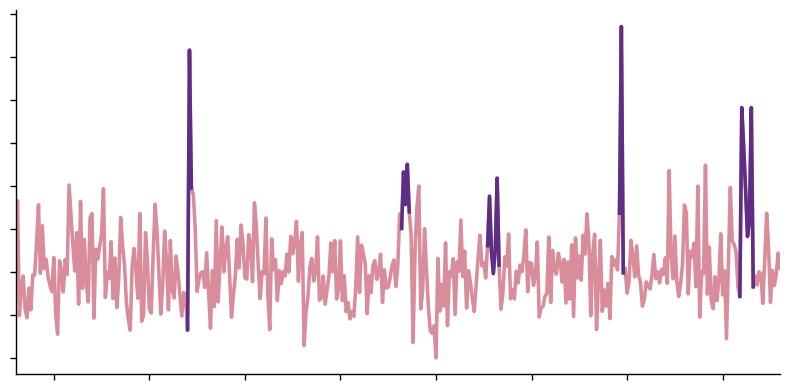

In [112]:
result = plot_patch_motion_curve_auto_units(
    motion_data=motion_patches,
    patch_coord=(105, 105),
    plot_range=(280,680),
    # 如果你有 restMotion 对应裁剪区域，推荐传入
    rest_motion=None,

    # 没有 restMotion 时，用自动阈值
    auto_percentile=90,

    # 去时间中位数
    median_window=45,

    # Motion Unit 提取参数，类似你的算法
    detect_on="raw",
    extend_radius=1,
    merge_gap=2,
    min_duration=1,

base_color="#D98C9A",
unit_color="#5E2E86",

    linewidth=2.56,
    figsize=(8, 4),
    save_path="patch_motion_units_demo.pdf",
    dpi=600,
)


#### 图例

In [125]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def save_motion_unit_legend(
    save_path="motion_unit_legend.pdf",
    unit_color="#6A3D91",
    base_color="#E8A9B0",
    unit_label="Motion units",
    base_label="Resting motion",
    linewidth=3.0,
    fontsize=12,
    figsize=(2.6, 0.7),
    ncol=2,
    frameon=False,
    dpi=300,
    transparent=True,
):
    """
    单独保存 motion curve 的图例。

    默认：
    - 紫色线：Motion units
    - 粉色线：Resting motion
    """

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    handles = [
        Line2D(
            [0],
            [0],
            color=unit_color,
            linewidth=linewidth,
            linestyle="-",
            label=unit_label,
        ),
        Line2D(
            [0],
            [0],
            color=base_color,
            linewidth=linewidth,
            linestyle="-",
            label=base_label,
        ),
    ]

    legend = ax.legend(
        handles=handles,
        loc="center",
        frameon=frameon,
        fontsize=fontsize,
        ncol=ncol,
        handlelength=2.2,
        handletextpad=0.6,
        columnspacing=1.2,
        borderaxespad=0,
    )

    plt.savefig(
        save_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.02,
        transparent=transparent,
    )
    plt.close(fig)

    print(f"Legend saved to: {save_path}")


save_motion_unit_legend(
    save_path="motion_unit_legend.pdf",
    base_color="#D98C9A",
    unit_color="#5E2E86",
    unit_label="Motion units",
    base_label="Resting motion",
    linewidth=3.0,
    fontsize=14,
    figsize=(2.2, 1.1),
    ncol=1
)


Legend saved to: motion_unit_legend.pdf


#### Episodes images

In [ ]:
from matplotlib.colors import ListedColormap
import numpy as np
import sys
import types
from utils import motion_stage_cache as msc
from utils import motion_correlation_pattern as mcp
from utils import motion_episodes as 
fake_src_registration = types.ModuleType("src_registration")
fake_src_registration.__path__ = []  
sys.modules["src_registration"] = fake_src_registration
sys.modules["src_registration.motion_correlation_pattern"] = mcp
setattr(fake_src_registration, "motion_correlation_pattern", mcp)
cache_root = Path("/home/cyf/wbi/wbi_code/data/F338_Slice7_frameAll")
episodes = msc.load_episodes_stage(
    cache_root
)

# unit_cmap = ListedColormap([
#     "#E8A9B0",  # 0: 非 motion unit / resting
#     "#6A3D91",  # 1: motion unit
# ])


#### 画motion episode

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path
import copy


def motion_to_magnitude_image(motion, region_mask):
    """
    将 episode.motion 转成 (T, H, W) 的 motion magnitude image。

    支持以下格式：
    1. (T, H, W, 2/3)  -> 直接 norm
    2. (T, H, W)       -> 已经是 magnitude
    3. (T, N, 2/3)     -> norm 后根据 region_mask 填回全图
    4. (T, N)          -> 根据 region_mask 填回全图
    5. (T, H*W, 2/3)   -> norm 后 reshape 回全图
    6. (T, H*W)        -> reshape 回全图
    """

    motion = np.asarray(motion)
    region_mask = np.asarray(region_mask).astype(bool)

    H, W = region_mask.shape
    area = int(region_mask.sum())

    # -------------------------
    # Case 1: full vector field, (T, H, W, 2/3)
    # -------------------------
    if motion.ndim == 4 and motion.shape[-1] in [2, 3]:
        mag = np.linalg.norm(motion, axis=-1)

        if mag.shape[1:] != (H, W):
            raise ValueError(
                f"Full motion field shape {mag.shape[1:]} does not match mask shape {(H, W)}"
            )

        return mag.astype(np.float32, copy=False)

    # -------------------------
    # Case 2: full magnitude field, (T, H, W)
    # -------------------------
    if motion.ndim == 3 and motion.shape[1:] == (H, W):
        return motion.astype(np.float32, copy=False)

    # -------------------------
    # Case 3: flattened vector field, (T, N, 2/3)
    # -------------------------
    if motion.ndim == 3 and motion.shape[-1] in [2, 3]:
        mag_flat = np.linalg.norm(motion, axis=-1)  # (T, N)
        T, N = mag_flat.shape

        # N 等于 episode 区域面积：填回 mask 内部
        if N == area:
            mag_img = np.full((T, H, W), np.nan, dtype=np.float32)
            mag_img[:, region_mask] = mag_flat.astype(np.float32)
            return mag_img

        # N 等于全图像素数：reshape 回全图
        elif N == H * W:
            return mag_flat.reshape(T, H, W).astype(np.float32, copy=False)

        else:
            raise ValueError(
                f"Flattened vector motion has N={N}, but mask area={area}, H*W={H*W}. "
                "Cannot map it back to image grid."
            )

    # -------------------------
    # Case 4: flattened magnitude, (T, N)
    # -------------------------
    if motion.ndim == 2:
        T, N = motion.shape

        # N 等于 episode 区域面积：填回 mask 内部
        if N == area:
            mag_img = np.full((T, H, W), np.nan, dtype=np.float32)
            mag_img[:, region_mask] = motion.astype(np.float32)
            return mag_img

        # N 等于全图像素数：reshape 回全图
        elif N == H * W:
            return motion.reshape(T, H, W).astype(np.float32, copy=False)

        else:
            raise ValueError(
                f"Flattened magnitude motion has N={N}, but mask area={area}, H*W={H*W}. "
                "Cannot map it back to image grid."
            )

    raise ValueError(
        f"Unsupported motion shape: {motion.shape}. "
        "Expected (T,H,W,2), (T,H,W), (T,N,2), or (T,N)."
    )


def _get_bbox_from_mask(mask, margin=0):
    """
    根据 episode spatial mask 计算固定 bbox。
    所有帧都用同一个 bbox，因此空间显示范围一致。
    """
    mask = np.asarray(mask).astype(bool)
    ys, xs = np.where(mask)

    if len(ys) == 0 or len(xs) == 0:
        raise ValueError("The episode spatial_region is empty.")

    y0 = max(0, ys.min() - margin)
    y1 = min(mask.shape[0], ys.max() + 1 + margin)
    x0 = max(0, xs.min() - margin)
    x1 = min(mask.shape[1], xs.max() + 1 + margin)

    return y0, y1, x0, x1


def _resolve_cmap(cmap, transparent_outside=True):
    """
    支持两种输入：
    1. cmap 是字符串，例如 "plasma"
    2. cmap 是 matplotlib colormap 对象，例如 LinearSegmentedColormap
    """
    if isinstance(cmap, str):
        cmap_use = copy.copy(plt.get_cmap(cmap))
    else:
        cmap_use = copy.copy(cmap)

    if transparent_outside:
        cmap_use.set_bad(alpha=0.0)

    return cmap_use


def plot_motion_episode_frames_clean(
    episode,
    motion_attr="motion",
    save_dir="./episode_vis",
    prefix=None,

    # 空间显示
    crop_to_region=True,
    margin=5,

    # 颜色控制
    cmap="plasma",
    vmin=None,
    vmax=None,

    # 输出控制
    dpi=300,
    fig_long_side=4.0,
    interpolation="nearest",
    transparent_outside=True,
    transparent_bg=True,
    show=False,

    # 可选边界线，默认不画，保证主图干净
    draw_boundary=False,
    boundary_color="white",
    boundary_linewidth=0.8,
    background_color="#F2F2F2"
):
    """
    干净版 MotionEpisode 逐帧可视化。

    特点：
    - 每一帧保存为 PNG
    - 无标题
    - 无坐标轴
    - 无图像边框
    - 无 colorbar
    - 只显示 episode.spatial_region 内部
    - 支持用户指定 cmap, vmin, vmax
    - 所有帧使用同一个空间 crop 和同一个颜色范围

    参数
    ----
    episode:
        MotionEpisode 对象。

    motion_attr:
        使用哪个 motion 属性。
        常用：
            "motion"      : delta motion
            "motion_abs"  : cumulative / absolute motion

    save_dir:
        PNG 保存文件夹。

    prefix:
        输出文件名前缀。若为 None，则使用 episode_{episode_id}。

    cmap:
        可以是 matplotlib 内置 cmap 名称，例如 "plasma"；
        也可以是自定义 colormap 对象。

    vmin, vmax:
        指定颜色对应的数值范围。
        若为 None，则自动根据该 episode 内部所有帧的有效值计算。

    transparent_outside:
        True 时，episode 区域外透明。

    transparent_bg:
        True 时，整张 PNG 背景透明。

    draw_boundary:
        是否额外画 episode 区域边界。
        你现在想要干净图，建议保持 False。

    返回
    ----
    out_paths:
        每一帧 PNG 的保存路径列表。
    """

    # -------------------------
    # 1. 时间范围
    # -------------------------
    t0, t1 = map(int, episode.time_range)
    n_expected = t1 - t0 + 1

    # -------------------------
    # 2. 取 motion 和 region mask
    # -------------------------
    motion_data = getattr(episode, motion_attr, None)
    if motion_data is None:
        raise ValueError(f"episode.{motion_attr} is None")

    region_mask = np.asarray(episode.spatial_region).astype(bool)
    if region_mask.ndim != 2:
        raise ValueError(
            f"episode.spatial_region should be 2D, but got shape {region_mask.shape}"
        )

    mag = motion_to_magnitude_image(motion_data, region_mask=region_mask)

    # -------------------------
    # 3. 兼容局部时间段 or 全局时间段
    # -------------------------
    if mag.shape[0] == n_expected:
        mag_use = mag
        frame_ids = list(range(t0, t1 + 1))
    elif mag.shape[0] >= (t1 + 1):
        mag_use = mag[t0:t1 + 1]
        frame_ids = list(range(t0, t1 + 1))
    else:
        raise ValueError(
            f"Motion time dimension mismatch: motion has {mag.shape[0]} frames, "
            f"but episode time_range={episode.time_range} implies {n_expected} frames."
        )

    if mag_use.shape[1:] != region_mask.shape:
        raise ValueError(
            f"Mask shape {region_mask.shape} does not match motion frame shape {mag_use.shape[1:]}"
        )

    # -------------------------
    # 4. 固定空间显示范围
    # -------------------------
    if crop_to_region:
        y0, y1, x0, x1 = _get_bbox_from_mask(region_mask, margin=margin)
    else:
        y0, y1, x0, x1 = 0, region_mask.shape[0], 0, region_mask.shape[1]

    mask_crop = region_mask[y0:y1, x0:x1]

    # -------------------------
    # 5. 颜色范围
    # -------------------------
    vals_inside = mag_use[:, region_mask]

    if np.all(~np.isfinite(vals_inside)):
        raise ValueError("All motion values inside episode region are NaN or Inf.")

    if vmin is None:
        vmin = float(np.nanmin(vals_inside))
    if vmax is None:
        vmax = float(np.nanmax(vals_inside))

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-8

    cmap_use = _resolve_cmap(cmap, transparent_outside=False)
    cmap_use.set_bad(color=background_color, alpha=1.0)

    # -------------------------
    # 6. 输出目录
    # -------------------------
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if prefix is None:
        prefix = f"episode_{episode.episode_id}"

    out_paths = []

    # 根据 crop 的长宽比自动设置画布，避免图像被压缩
    Hc = y1 - y0
    Wc = x1 - x0
    if Hc >= Wc:
        figsize = (fig_long_side * Wc / Hc, fig_long_side)
    else:
        figsize = (fig_long_side, fig_long_side * Hc / Wc)

    # -------------------------
    # 7. 逐帧保存 PNG
    # -------------------------
    for i in range(mag_use.shape[0]):
        frame_mag = mag_use[i, y0:y1, x0:x1]

        # 区域外不显示
        frame_masked = np.ma.array(
            frame_mag,
            mask=(~mask_crop) | (~np.isfinite(frame_mag))
        )

        fig = plt.figure(
            figsize=figsize,
            dpi=dpi,
            frameon=False,
            facecolor=background_color,
        )

        # 让图像占满整个 figure，避免白边、坐标轴、边框
        ax = fig.add_axes([0, 0, 1, 1])
        ax.set_facecolor(background_color)
        ax.imshow(
            frame_masked,
            cmap=cmap_use,
            vmin=vmin,
            vmax=vmax,
            interpolation=interpolation,
        )

        if draw_boundary:
            ax.contour(
                mask_crop.astype(float),
                levels=[0.5],
                colors=boundary_color,
                linewidths=boundary_linewidth,
            )

        # 去掉标题、坐标轴、边框
        ax.set_axis_off()
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        out_path = save_dir / f"{prefix}_t{frame_ids[i]:04d}.png"
        fig.savefig(
            out_path,
            format="png",
            dpi=dpi,
            transparent=transparent_bg,
            bbox_inches="tight",
            pad_inches=0,
        )

        out_paths.append(out_path)

        if show:
            plt.show()

        plt.close(fig)

    return out_paths


def save_motion_colorbar_png(
    save_path,
    cmap="plasma",
    vmin=0,
    vmax=1,
    label=None,
    orientation="vertical",
    figsize=(0.45, 3.0),
    dpi=300,
    transparent_bg=True,
    background_color="#F2F2F2"
):
    """
    单独保存 colorbar 为 PNG。

    你主图不需要图注时，可以用这个函数单独导出图例，
    然后在 PPT / AI / Illustrator 里拼接。

    参数
    ----
    save_path:
        图例保存路径，例如 "./episode_vis/motion_colorbar.png"

    cmap:
        与主图一致的 colormap。

    vmin, vmax:
        与主图一致的颜色数值范围。

    label:
        colorbar 标签。若不想要文字，设为 None。

    orientation:
        "vertical" 或 "horizontal"。
    """

    cmap_use = _resolve_cmap(cmap, transparent_outside=False)

    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(norm=norm, cmap=cmap_use)
    sm.set_array([])

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    cbar = fig.colorbar(sm, cax=ax, orientation=orientation)

    if label is not None:
        cbar.set_label(label)

    fig.savefig(
        save_path,
        format="png",
        dpi=dpi,
        transparent=False,
        facecolor=background_color,
        bbox_inches="tight",
        pad_inches=0.02,
    )
    plt.close(fig)

    return save_path

In [33]:
ep = episodes[0]

print("time_range:", ep.time_range)
print("spatial_region shape:", ep.spatial_region.shape)
print("spatial_region area:", np.sum(ep.spatial_region > 0))

print("motion shape:", np.asarray(ep.motion).shape)
print("motion_abs shape:", None if ep.motion_abs is None else np.asarray(ep.motion_abs).shape)

cell_heat = LinearSegmentedColormap.from_list(
    "nature_blue_red",
    ["#1464B5", "#CDCDFF", "#BC081D"]
)

out_paths = plot_motion_episode_frames_clean(
    episodes[0],
    motion_attr="motion",          # 也可以改成 "motion_abs"
    save_dir="./Fig1.C_motion/episode_vis",
    prefix="ep0",

    cmap=cell_heat,
    vmin=-5,
    vmax=15,

    crop_to_region=True,
    margin=5,

    dpi=300,
    fig_long_side=4.0,

    transparent_outside=True,
    transparent_bg=True,

    draw_boundary=False,           # 主图干净，不画边界
    show=False,
)

time_range: [1053, 1058]
spatial_region shape: (329, 244)
spatial_region area: 23674
motion shape: (6, 23674, 2)
motion_abs shape: (6, 23674, 2)


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def _remove_small_components(binary_mask, min_area=1, connectivity=1):
    """
    Remove small connected components from a 2D binary mask.

    min_area <= 1 时不处理。
    """
    if min_area is None or min_area <= 1:
        return binary_mask

    from scipy.ndimage import label

    if connectivity == 1:
        structure = np.array(
            [[0, 1, 0],
             [1, 1, 1],
             [0, 1, 0]],
            dtype=bool,
        )
    else:
        structure = np.ones((3, 3), dtype=bool)

    labeled, n = label(binary_mask, structure=structure)

    if n == 0:
        return binary_mask

    out = np.zeros_like(binary_mask, dtype=bool)

    for k in range(1, n + 1):
        comp = labeled == k
        if comp.sum() >= min_area:
            out[comp] = True

    return out

import numpy as np
from scipy.ndimage import label


def filter_connected_components(
    binary_mask,
    area_threshold=4,
    mode="large",
    connectivity=1,
):
    """
    对二值图做连通分支分析，并按面积筛选。

    Parameters
    ----------
    binary_mask : 2D bool array

    area_threshold : int
        面积阈值

    mode : str
        - "all"   : 保留全部连通分支
        - "large" : 保留面积 >= area_threshold 的分支
        - "small" : 保留面积 <= area_threshold 的分支

    connectivity : int
        1 -> 4邻域
        2 -> 8邻域

    Returns
    -------
    filtered_mask : 2D bool array
    component_masks : list of 2D bool arrays
        保留下来的每一个连通分支 mask
    """
    binary_mask = np.asarray(binary_mask).astype(bool)

    if connectivity == 1:
        structure = np.array(
            [[0, 1, 0],
             [1, 1, 1],
             [0, 1, 0]],
            dtype=bool
        )
    else:
        structure = np.ones((3, 3), dtype=bool)

    labeled, n_comp = label(binary_mask, structure=structure)

    filtered_mask = np.zeros_like(binary_mask, dtype=bool)
    component_masks = []

    for k in range(1, n_comp + 1):
        comp = (labeled == k)
        area = int(comp.sum())

        keep = False
        if mode == "all":
            keep = True
        elif mode == "large":
            keep = area >= area_threshold
        elif mode == "small":
            keep = area <= area_threshold
        else:
            raise ValueError("mode 必须是 'all', 'large', 或 'small'")

        if keep:
            filtered_mask[comp] = True
            component_masks.append(comp)

    return filtered_mask, component_masks




    episode,
    motion_attr="motion",
    save_dir="./episode_threshold_regions",
    prefix=None,

    # threshold settings
    threshold=None,
    threshold_percentile=None,
    threshold_on="episode",  # "episode" or "frame"

    # spatial display
    crop_to_region=True,
    margin=5,

    # binary region style
    region_color="#6A3D91",
    region_alpha=1.0,

    # optional clean-up
    min_area=1,
    connectivity=1,

    # output
    dpi=300,
    fig_long_side=4.0,
    interpolation="nearest",
    show=False,


import matplotlib.pyplot as plt
from pathlib import Path


def _hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16) / 255.0
    g = int(hex_color[2:4], 16) / 255.0
    b = int(hex_color[4:6], 16) / 255.0
    return (r, g, b, alpha)


def plot_motion_episode_threshold_regions_with_boundary(
    episode,
    motion_attr="motion",
    save_dir="./episode_threshold_regions",
    prefix=None,

    # threshold
    threshold=None,
    threshold_percentile=None,
    threshold_on="episode",  # "episode" or "frame"

    # spatial display
    crop_to_region=True,
    margin=5,

    # region style
    region_color="#8E24AA",
    region_alpha=1.0,

    # connected component filter
    component_mode="large",      # "all", "large", "small"
    component_area_threshold=4,
    connectivity=1,

    # boundary style
    draw_component_boundary=True,
    boundary_color="white",
    boundary_linewidth=1.2,

    # output
    dpi=300,
    fig_long_side=4.0,
    interpolation="nearest",
    show=False,
):
    """
    只显示 motion magnitude 大于阈值的区域，背景透明，
    并支持连通分支筛选与描边。
    """
    # -------------------------
    # 1. 时间范围
    # -------------------------
    t0, t1 = map(int, episode.time_range)
    n_expected = t1 - t0 + 1

    # -------------------------
    # 2. 取 motion / region
    # -------------------------
    motion_data = getattr(episode, motion_attr, None)
    if motion_data is None:
        raise ValueError(f"episode.{motion_attr} is None")

    region_mask = np.asarray(episode.spatial_region).astype(bool)

    mag = motion_to_magnitude_image(
        motion_data,
        region_mask=region_mask,
    )

    # -------------------------
    # 3. 兼容时间
    # -------------------------
    if mag.shape[0] == n_expected:
        mag_use = mag
        frame_ids = list(range(t0, t1 + 1))
    elif mag.shape[0] >= (t1 + 1):
        mag_use = mag[t0:t1 + 1]
        frame_ids = list(range(t0, t1 + 1))
    else:
        raise ValueError(
            f"Motion time dimension mismatch: motion has {mag.shape[0]} frames, "
            f"but episode time_range={episode.time_range} implies {n_expected} frames."
        )

    # -------------------------
    # 4. crop
    # -------------------------
    if crop_to_region:
        y0, y1, x0, x1 = _get_bbox_from_mask(region_mask, margin=margin)
    else:
        y0, y1, x0, x1 = 0, region_mask.shape[0], 0, region_mask.shape[1]

    mask_crop = region_mask[y0:y1, x0:x1]
    Hc, Wc = mask_crop.shape

    # -------------------------
    # 5. threshold
    # -------------------------
    vals_inside = mag_use[:, region_mask]
    vals_inside = vals_inside[np.isfinite(vals_inside)]

    if vals_inside.size == 0:
        raise ValueError("No finite motion values inside episode region.")

    if threshold is None and threshold_percentile is None:
        raise ValueError("请指定 threshold 或 threshold_percentile")

    if threshold is not None:
        threshold_global = float(threshold)
    else:
        if threshold_on == "episode":
            threshold_global = float(np.nanpercentile(vals_inside, threshold_percentile))
        elif threshold_on == "frame":
            threshold_global = None
        else:
            raise ValueError("threshold_on 必须是 'episode' 或 'frame'")

    # -------------------------
    # 6. 输出目录
    # -------------------------
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if prefix is None:
        prefix = f"episode_{episode.episode_id}_threshold"

    if Hc >= Wc:
        figsize = (fig_long_side * Wc / Hc, fig_long_side)
    else:
        figsize = (fig_long_side, fig_long_side * Hc / Wc)

    rgba_color = _hex_to_rgba(region_color, alpha=region_alpha)

    out_paths = []

    # -------------------------
    # 7. 逐帧画图
    # -------------------------
    for i in range(mag_use.shape[0]):
        frame_mag = mag_use[i, y0:y1, x0:x1]

        if threshold is not None:
            thr = threshold_global
        elif threshold_on == "episode":
            thr = threshold_global
        else:
            frame_vals = frame_mag[mask_crop & np.isfinite(frame_mag)]
            if frame_vals.size == 0:
                thr = np.inf
            else:
                thr = float(np.nanpercentile(frame_vals, threshold_percentile))

        binary_region = (
            mask_crop
            & np.isfinite(frame_mag)
            & (frame_mag > thr)
        )

        filtered_mask, component_masks = filter_connected_components(
            binary_region,
            area_threshold=component_area_threshold,
            mode=component_mode,
            connectivity=connectivity,
        )

        rgba = np.zeros((Hc, Wc, 4), dtype=np.float32)
        rgba[filtered_mask, :] = rgba_color

        fig = plt.figure(
            figsize=figsize,
            dpi=dpi,
            frameon=False,
            facecolor=(0, 0, 0, 0),
        )
        ax = fig.add_axes([0, 0, 1, 1])

        ax.imshow(rgba, interpolation=interpolation)

        # 对每个连通分支描边
        if draw_component_boundary:
            for comp in component_masks:
                ax.contour(
                    comp.astype(float),
                    levels=[0.5],
                    colors=boundary_color,
                    linewidths=boundary_linewidth,
                )

        ax.set_axis_off()
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        out_path = save_dir / f"{prefix}_t{frame_ids[i]:04d}.png"

        fig.savefig(
            out_path,
            format="png",
            dpi=dpi,
            transparent=True,
            bbox_inches="tight",
            pad_inches=0,
        )

        out_paths.append(out_path)

        if show:
            plt.show()

        plt.close(fig)

    return out_paths

In [50]:
out_paths = plot_motion_episode_threshold_regions_with_boundary(
    episode=episodes[0],
    motion_attr="motion_abs",
    save_dir="./Fig1.C_motion/episode_regions",
    threshold_percentile=80,
    threshold_on="episode",

    region_color="#5CB8B2",      # 显眼紫色
    region_alpha=1.0,

    component_mode="large",      # 只保留大块
    component_area_threshold=30,  # 面积至少4个像素
    connectivity=2,

    draw_component_boundary=True,
    boundary_color="#2E7D78",
    boundary_linewidth=2,

    dpi=600,
)

In [53]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
})

# formula = r"""
# $\displaystyle
# \min_{B,H}
# \left\| M - BH \right\|_F^2
# +
# \lambda_B \sum_{i,k} \left\| b_{ik} \right\|_2
# +
# \lambda_H \sum_k \left\| D^2 h_k \right\|_2^2
# $
# """
formula = r"""
$\displaystyle
\min_{B,H}
\| M - BH \|_F^2
+
\lambda_B \sum_{i,k} \| b_{ik} \|_2
+
\lambda_H \sum_k \| D^2 h_k \|_2^2
$
"""
fig, ax = plt.subplots(figsize=(8, 1.2))
ax.text(
    0.5,
    0.5,
    formula,
    ha="center",
    va="center",
    fontsize=22,
)

ax.axis("off")

plt.savefig(
    "formula.pdf",
    bbox_inches="tight",
    pad_inches=0.05,
    transparent=True,
)

plt.savefig(
    "formula.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05,
    transparent=True,
)

plt.close(fig)

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter, binary_fill_holes
from scipy.spatial import ConvexHull
from matplotlib.path import Path as MplPath
import copy


# ============================================================
# 1. 基础工具
# ============================================================

def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16) / 255.0
    g = int(hex_color[2:4], 16) / 255.0
    b = int(hex_color[4:6], 16) / 255.0
    return (r, g, b, alpha)


def get_bbox_from_mask(mask, margin=8):
    ys, xs = np.where(mask)
    if len(ys) == 0:
        raise ValueError("mask is empty")

    y0 = max(0, ys.min() - margin)
    y1 = min(mask.shape[0], ys.max() + 1 + margin)
    x0 = max(0, xs.min() - margin)
    x1 = min(mask.shape[1], xs.max() + 1 + margin)
    return y0, y1, x0, x1


def get_auto_figsize(H, W, fig_long_side=4.0):
    if H >= W:
        return (fig_long_side * W / H, fig_long_side)
    else:
        return (fig_long_side, fig_long_side * H / W)


# ============================================================
# 2. 生成尽量凸、平滑的区域 mask
# ============================================================

def generate_convex_region_mask(
    H=180,
    W=260,
    seed=0,
    n_vertices=11,
    center=None,
    radius_range=(40, 75),
    anisotropy=(1.0, 0.78),
    smooth_sigma=2.2,
):
    """
    生成一个尽量凸、形状自然的区域。
    思路：
    - 在中心附近生成若干随机顶点
    - 求凸包
    - 填充 polygon
    - 轻微平滑边缘
    """
    rng = np.random.default_rng(seed)

    if center is None:
        cy = H * 0.5
        cx = W * 0.5
    else:
        cy, cx = center

    angles = np.sort(rng.uniform(0, 2 * np.pi, size=n_vertices))
    radii = rng.uniform(radius_range[0], radius_range[1], size=n_vertices)

    ay, ax = anisotropy

    points = []
    for a, r in zip(angles, radii):
        y = cy + ay * r * np.sin(a)
        x = cx + ax * r * np.cos(a)
        points.append([y, x])

    points = np.asarray(points)

    hull = ConvexHull(points)
    hull_pts = points[hull.vertices]

    yy, xx = np.mgrid[0:H, 0:W]
    coords = np.vstack((yy.ravel(), xx.ravel())).T

    # Path 用的是 (x, y) 坐标
    poly_path = MplPath(hull_pts[:, [1, 0]])
    mask = poly_path.contains_points(coords[:, [1, 0]]).reshape(H, W)

    # 轻微平滑
    mask_smooth = gaussian_filter(mask.astype(float), sigma=smooth_sigma) > 0.5
    mask_smooth = binary_fill_holes(mask_smooth)

    return mask_smooth.astype(bool)


# ============================================================
# 3. 生成允许正负的时间序列
# ============================================================

def generate_signed_demo_timeseries(
    T=120,
    seed=0,
    pulses=None,
    noise_std=0.04,
):
    """
    生成一条可正可负的示意性时间序列。
    """
    rng = np.random.default_rng(seed)
    t = np.arange(T)

    # 平滑基线振荡
    y = (
        0.18 * np.sin(2 * np.pi * t / 38.0)
        + 0.10 * np.sin(2 * np.pi * t / 17.0 + 0.6)
    )

    # 正负脉冲
    if pulses is None:
        pulses = [
            {"center": 18, "amp":  0.9, "width": 5},
            {"center": 42, "amp": -0.7, "width": 8},
            {"center": 74, "amp":  1.1, "width": 6},
            {"center": 101, "amp": -0.5, "width": 5},
        ]

    for p in pulses:
        c = p["center"]
        a = p["amp"]
        w = p["width"]
        y += a * np.exp(-0.5 * ((t - c) / w) ** 2)

    y += noise_std * rng.normal(size=T)
    return t, y


# ============================================================
# 4. 生成平滑向量场（不是中心向外）
# ============================================================

def generate_smooth_vector_field(
    mask,
    seed=0,
    sigma=18.0,
    flow_bias=(1.0, 0.15),
    rotational_strength=0.20,
):
    """
    生成一个平滑的二维向量场 U, V。
    """
    rng = np.random.default_rng(seed)
    H, W = mask.shape

    noise_u = gaussian_filter(rng.normal(size=(H, W)), sigma=sigma)
    noise_v = gaussian_filter(rng.normal(size=(H, W)), sigma=sigma)

    yy, xx = np.mgrid[0:H, 0:W]
    cy = H / 2
    cx = W / 2

    # 一个轻微旋转项，但不是主导
    rot_u = -(yy - cy)
    rot_v = (xx - cx)
    rot_norm = np.sqrt(rot_u ** 2 + rot_v ** 2) + 1e-8
    rot_u = rot_u / rot_norm
    rot_v = rot_v / rot_norm

    U = noise_u + flow_bias[0] + rotational_strength * rot_u
    V = noise_v + flow_bias[1] + rotational_strength * rot_v

    U = gaussian_filter(U, sigma=sigma / 2)
    V = gaussian_filter(V, sigma=sigma / 2)

    return U, V


# ============================================================
# 5. 在 mask 内均匀采样箭头位置
# ============================================================

def sample_arrow_positions_on_mask(mask, step=14, margin=3):
    """
    在 mask 内按规则网格采样箭头位置，避免太随机或太拥挤。
    """
    H, W = mask.shape
    ys = np.arange(margin, H - margin, step)
    xs = np.arange(margin, W - margin, step)

    pts_y = []
    pts_x = []

    for y in ys:
        for x in xs:
            if mask[y, x]:
                pts_y.append(y)
                pts_x.append(x)

    return np.asarray(pts_x), np.asarray(pts_y)


# ============================================================
# 6. 生成平滑标量场，用于底色
# ============================================================

def generate_smooth_scalar_field(
    mask,
    U,
    V,
    mode="projection",   # "projection" or "magnitude"
    smooth_sigma=8,
):
    """
    在 region 内生成一个平滑标量场，用于着色。
    """
    H, W = mask.shape
    yy, xx = np.mgrid[0:H, 0:W]

    if mode == "magnitude":
        S = np.sqrt(U ** 2 + V ** 2)

    elif mode == "projection":
        mean_u = np.nanmean(U[mask])
        mean_v = np.nanmean(V[mask])

        norm = np.sqrt(mean_u ** 2 + mean_v ** 2) + 1e-8
        du = mean_u / norm
        dv = mean_v / norm

        cx = np.mean(xx[mask])
        cy = np.mean(yy[mask])

        S = (xx - cx) * du + (yy - cy) * dv
    else:
        raise ValueError("mode must be 'projection' or 'magnitude'")

    S = gaussian_filter(S, sigma=smooth_sigma)
    S = np.where(mask, S, np.nan)

    vals = S[mask]
    S = (S - np.nanmin(vals)) / (np.nanmax(vals) - np.nanmin(vals) + 1e-8)

    return S


# ============================================================
# 7. 图1：只画区域
# ============================================================

def plot_region_only(
    mask,
    save_path="region_only.png",
    fill_color="#8E6BBE",
    edge_color="#5E3C99",
    edge_width=1.5,
    margin=8,
    fig_long_side=4.0,
    dpi=300,
    transparent_bg=True,
):
    y0, y1, x0, x1 = get_bbox_from_mask(mask, margin=margin)
    crop = mask[y0:y1, x0:x1]

    Hc, Wc = crop.shape
    figsize = get_auto_figsize(Hc, Wc, fig_long_side=fig_long_side)

    rgba = np.zeros((Hc, Wc, 4), dtype=np.float32)
    rgba[crop] = hex_to_rgba(fill_color, alpha=1.0)

    fig = plt.figure(figsize=figsize, dpi=dpi, frameon=False)
    ax = fig.add_axes([0, 0, 1, 1])

    ax.imshow(rgba, interpolation="nearest")
    ax.contour(
        crop.astype(float),
        levels=[0.5],
        colors=[edge_color],
        linewidths=edge_width,
    )

    ax.set_axis_off()
    ax.set_xticks([])
    ax.set_yticks([])

    fig.savefig(
        save_path,
        dpi=dpi,
        transparent=transparent_bg,
        bbox_inches="tight",
        pad_inches=0,
    )
    plt.close(fig)

    return {
        "bbox": (y0, y1, x0, x1),
        "figsize": figsize,
        "crop_shape": crop.shape,
    }


# ============================================================
# 8. 图2：时间序列曲线（允许正负）
# ============================================================

def plot_timeseries_curve(
    t,
    y,
    save_path="timeseries.png",
    line_color="#6A3D91",
    lw=2.4,
    zero_line=True,
    zero_color="#BBBBBB",
    zero_lw=1.0,
    figsize=(4.4, 2.1),
    dpi=300,
    transparent_bg=True,
):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    ax.plot(t, y, color=line_color, linewidth=lw)

    if zero_line:
        ax.axhline(0, color=zero_color, linewidth=zero_lw, linestyle="--", zorder=0)

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.grid(False)

    ax.tick_params(
        axis="both",
        which="both",
        length=4,
        width=1.0,
        labelbottom=False,
        labelleft=False,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    fig.savefig(
        save_path,
        dpi=dpi,
        transparent=transparent_bg,
        bbox_inches="tight",
        pad_inches=0.02,
    )
    plt.close(fig)


# ============================================================
# 9. 图3：同样大小的区域图 + 平滑着色 + 箭头
# ============================================================

def plot_region_with_vector_overlay(
    mask,
    save_path="region_with_vectors.png",
    cmap="PuBuGn",
    edge_color="#2E7D78",
    edge_width=1.2,
    arrow_color="#5E3C99",
    arrow_length=9.0,
    arrow_width=0.007,
    arrow_step=14,
    vector_sigma=18.0,
    flow_bias=(1.0, 0.15),
    rotational_strength=0.20,
    scalar_mode="projection",
    margin=8,
    fig_long_side=4.0,
    dpi=300,
    transparent_bg=True,
    seed=0,
):
    y0, y1, x0, x1 = get_bbox_from_mask(mask, margin=margin)
    crop_mask = mask[y0:y1, x0:x1]

    Hc, Wc = crop_mask.shape
    figsize = get_auto_figsize(Hc, Wc, fig_long_side=fig_long_side)

    # 全图平滑向量场
    U, V = generate_smooth_vector_field(
        mask,
        seed=seed,
        sigma=vector_sigma,
        flow_bias=flow_bias,
        rotational_strength=rotational_strength,
    )

    # 底色标量场
    S = generate_smooth_scalar_field(
        mask,
        U,
        V,
        mode=scalar_mode,
    )

    crop_U = U[y0:y1, x0:x1]
    crop_V = V[y0:y1, x0:x1]
    crop_S = S[y0:y1, x0:x1]

    xs, ys = sample_arrow_positions_on_mask(
        crop_mask,
        step=arrow_step,
        margin=3,
    )

    u = crop_U[ys, xs]
    v = crop_V[ys, xs]

    # 统一箭头长度
    norm = np.sqrt(u ** 2 + v ** 2) + 1e-8
    u = arrow_length * u / norm
    v = arrow_length * v / norm

    fig = plt.figure(figsize=figsize, dpi=dpi, frameon=False)
    ax = fig.add_axes([0, 0, 1, 1])

    cmap_use = copy.copy(plt.get_cmap(cmap))
    cmap_use.set_bad(alpha=0.0)

    masked_S = np.ma.array(
        crop_S,
        mask=(~crop_mask) | (~np.isfinite(crop_S))
    )

    ax.imshow(masked_S, cmap=cmap_use, interpolation="nearest")

    ax.contour(
        crop_mask.astype(float),
        levels=[0.5],
        colors=[edge_color],
        linewidths=edge_width,
    )

    ax.quiver(
        xs,
        ys,
        u,
        v,
        color=arrow_color,
        angles="xy",
        scale_units="xy",
        scale=1.0,
        width=arrow_width,
        headwidth=4.2,
        headlength=5.2,
        headaxislength=4.8,
    )

    ax.set_axis_off()
    ax.set_xticks([])
    ax.set_yticks([])

    fig.savefig(
        save_path,
        dpi=dpi,
        transparent=transparent_bg,
        bbox_inches="tight",
        pad_inches=0,
    )
    plt.close(fig)


# ============================================================
# 10. 总 pipeline：一次性生成三张图
# ============================================================

def make_demo_response_pipeline(
    out_dir="./demo_region_figs",
    # region
    H=180,
    W=260,
    region_seed=3,
    n_vertices=11,
    radius_range=(40, 75),
    anisotropy=(1.0, 0.78),
    smooth_sigma=2.2,

    # timeseries
    T=120,
    ts_seed=4,
    pulses=None,
    noise_std=0.04,

    # style: region only
    region_fill_color="#8E6BBE",
    region_edge_color="#5E3C99",
    region_edge_width=1.5,

    # style: timeseries
    line_color="#6A3D91",
    line_width=2.4,
    zero_line=True,
    zero_color="#BBBBBB",
    zero_lw=1.0,

    # style: overlay
    overlay_cmap="PuBuGn",
    overlay_edge_color="#2E7D78",
    overlay_edge_width=1.2,
    arrow_color="#5E3C99",
    arrow_length=9.0,
    arrow_width=0.007,
    arrow_step=14,
    vector_sigma=18.0,
    flow_bias=(1.0, 0.15),
    rotational_strength=0.20,
    scalar_mode="projection",
    overlay_seed=5,

    # global output
    margin=8,
    fig_long_side=4.2,
    ts_figsize=(4.6, 2.2),
    dpi=400,
    transparent_bg=True,
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # 1. region
    mask = generate_convex_region_mask(
        H=H,
        W=W,
        seed=region_seed,
        n_vertices=n_vertices,
        radius_range=radius_range,
        anisotropy=anisotropy,
        smooth_sigma=smooth_sigma,
    )

    region_path = out_dir / "region_only.png"
    plot_region_only(
        mask,
        save_path=region_path,
        fill_color=region_fill_color,
        edge_color=region_edge_color,
        edge_width=region_edge_width,
        margin=margin,
        fig_long_side=fig_long_side,
        dpi=dpi,
        transparent_bg=transparent_bg,
    )

    # 2. timeseries
    t, y = generate_signed_demo_timeseries(
        T=T,
        seed=ts_seed,
        pulses=pulses,
        noise_std=noise_std,
    )

    ts_path = out_dir / "timeseries.png"
    plot_timeseries_curve(
        t,
        y,
        save_path=ts_path,
        line_color=line_color,
        lw=line_width,
        zero_line=zero_line,
        zero_color=zero_color,
        zero_lw=zero_lw,
        figsize=ts_figsize,
        dpi=dpi,
        transparent_bg=transparent_bg,
    )

    # 3. overlay
    overlay_path = out_dir / "region_with_vectors.png"
    plot_region_with_vector_overlay(
        mask,
        save_path=overlay_path,
        cmap=overlay_cmap,
        edge_color=overlay_edge_color,
        edge_width=overlay_edge_width,
        arrow_color=arrow_color,
        arrow_length=arrow_length,
        arrow_width=arrow_width,
        arrow_step=arrow_step,
        vector_sigma=vector_sigma,
        flow_bias=flow_bias,
        rotational_strength=rotational_strength,
        scalar_mode=scalar_mode,
        margin=margin,
        fig_long_side=fig_long_side,
        dpi=dpi,
        transparent_bg=transparent_bg,
        seed=overlay_seed,
    )

    return {
        "mask": mask,
        "timeseries_t": t,
        "timeseries_y": y,
        "region_only_path": region_path,
        "timeseries_path": ts_path,
        "overlay_path": overlay_path,
    }


# ============================================================
# 11. 示例运行
# ============================================================

if __name__ == "__main__":
    result = make_demo_response_pipeline(
        out_dir="./demo_region_figs",

        # region
        H=180,
        W=260,
        region_seed=260603,
        n_vertices=11,
        radius_range=(40, 75),
        anisotropy=(1.0, 0.78),
        smooth_sigma=2.2,

        # timeseries
        T=120,
        ts_seed=4,
        pulses=[
            {"center": 18, "amp":  0.9, "width": 5},
            {"center": 42, "amp": -0.7, "width": 8},
            {"center": 74, "amp":  1.1, "width": 6},
            {"center": 101, "amp": -0.5, "width": 5},
        ],
        noise_std=0.04,

        # style
        region_fill_color="#8E6BBE",
        region_edge_color="#5E3C99",
        region_edge_width=1.5,

        line_color="#6A3D91",
        line_width=2.4,
        zero_line=True,
        zero_color="#BBBBBB",
        zero_lw=1.0,

        overlay_cmap="PuBuGn",
        overlay_edge_color="#2E7D78",
        overlay_edge_width=1.2,
        arrow_color="#5E3C99",
        arrow_length=9.0,
        arrow_width=0.007,
        arrow_step=14,
        vector_sigma=18.0,
        flow_bias=(1.0, 0.15),
        rotational_strength=0.20,
        scalar_mode="projection",
        overlay_seed=5,

        margin=8,
        fig_long_side=4.2,
        ts_figsize=(4.6, 2.2),
        dpi=400,
        transparent_bg=True,
    )

    print("Done.")
    print("region_only :", result["region_only_path"])
    print("timeseries  :", result["timeseries_path"])
    print("overlay     :", result["overlay_path"])

Done.
region_only : demo_region_figs/region_only.png
timeseries  : demo_region_figs/timeseries.png
overlay     : demo_region_figs/region_with_vectors.png
